# Notebook de Optimización: Método de Búsqueda Aleatoria

Este cuaderno implementa el método de optimización por Búsqueda Aleatoria para encontrar una aproximación al mínimo de una función dentro de un intervalo especificado. Además, visualiza la función con el punto óptimo encontrado y la convergencia del mejor valor a lo largo de las iteraciones.

## ¿Qué es el Método de Búsqueda Aleatoria?

La Búsqueda Aleatoria es una técnica de optimización sin derivadas. En cada iteración, se genera un punto candidato al azar dentro del dominio y se compara su valor con el mejor encontrado hasta el momento. Si mejora la solución, se actualiza el óptimo actual.

El algoritmo funciona de la siguiente manera para encontrar un mínimo en el intervalo `[a, b]`:

1. Se define un intervalo de búsqueda y un número de iteraciones.
2. Se genera un punto aleatorio `x_i` en `[a, b]`.
3. Se evalúa `f(x_i)`.
4. Si `f(x_i)` es menor que el mejor valor actual, se actualiza el mejor punto.
5. Se repite el proceso hasta completar todas las iteraciones.

Aunque no garantiza convergencia exacta como métodos analíticos, es simple, robusto y útil cuando no se dispone de derivadas o la función es compleja.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import inspect 

In [3]:
def funcion_ejemplo(x):
    return x**4 - 3*x**3 + x + 2


In [10]:
def busqueda_aleatoria_minimizacion(func, a, b, n_iter=2000, semilla=42):
    """
    Implementa Búsqueda Aleatoria para encontrar el mínimo de una función.

    Args:
        func (callable): Función a minimizar.
        a (float): Límite inferior del intervalo.
        b (float): Límite superior del intervalo.
        n_iter (int): Número de muestras aleatorias.
        semilla (int): Semilla para reproducibilidad.

    Returns:
        tuple: (x_opt, f_opt, historial_error)
               historial_error guarda (iteración, mejor_f_hasta_ahora).
    """
    if a >= b:
        raise ValueError("El intervalo debe cumplir a < b.")

    rng = np.random.default_rng(semilla)

    x_opt = rng.uniform(a, b)
    f_opt = func(x_opt)

    historial_error = [(0, f_opt)]

    for i in range(1, n_iter + 1):
        x_candidato = rng.uniform(a, b)
        f_candidato = func(x_candidato)

        if f_candidato < f_opt:
            x_opt = x_candidato
            f_opt = f_candidato

        historial_error.append((i, f_opt))

    return x_opt, f_opt, historial_error

def busqueda_aleatoria_maximizacion(func, a, b, n_iter=1000, semilla=42):
    """Encuentra un máximo maximizando f(x) vía minimización de -f(x)."""
    def neg_func(x):
        return -func(x)

    x_opt, neg_f_opt, historial_error_neg = busqueda_aleatoria_minimizacion(
        neg_func, a, b, n_iter=n_iter, semilla=semilla
    )

    historial_error = [(it, -val) for it, val in historial_error_neg]
    return x_opt, -neg_f_opt, historial_error

In [18]:
# Definir el intervalo inicial de búsqueda
a_intervalo = -5.0
b_intervalo = 5.0
fn= inspect.getsource(funcion_ejemplo).split("return")[-1].strip()
# Definir parámetros de la búsqueda
n_iteraciones = 300
semilla = 123

print(f"Buscando el mínimo de la función f(x) = {fn} en el intervalo [{a_intervalo}, {b_intervalo}]")
print(f"Con {n_iteraciones} iteraciones y semilla = {semilla}\n")

x_min_encontrado, f_min_encontrado, historial_error_min = busqueda_aleatoria_minimizacion(
    funcion_ejemplo, a_intervalo, b_intervalo, n_iter=n_iteraciones, semilla=semilla
)

print(f"Mínimo aproximado encontrado en x = {x_min_encontrado:.6f}")
print(f"Valor de la función en el mínimo aproximado = {f_min_encontrado:.6f}")
print(f"Número de iteraciones: {len(historial_error_min) - 1}")
print(f"Mejor valor final observado = {historial_error_min[-1][1]:.6e}\n")


Buscando el mínimo de la función f(x) = x**4 - 3*x**3 + x + 2 en el intervalo [-5.0, 5.0]
Con 300 iteraciones y semilla = 123

Mínimo aproximado encontrado en x = 2.248929
Valor de la función en el mínimo aproximado = -4.294028
Número de iteraciones: 300
Mejor valor final observado = -4.294028e+00



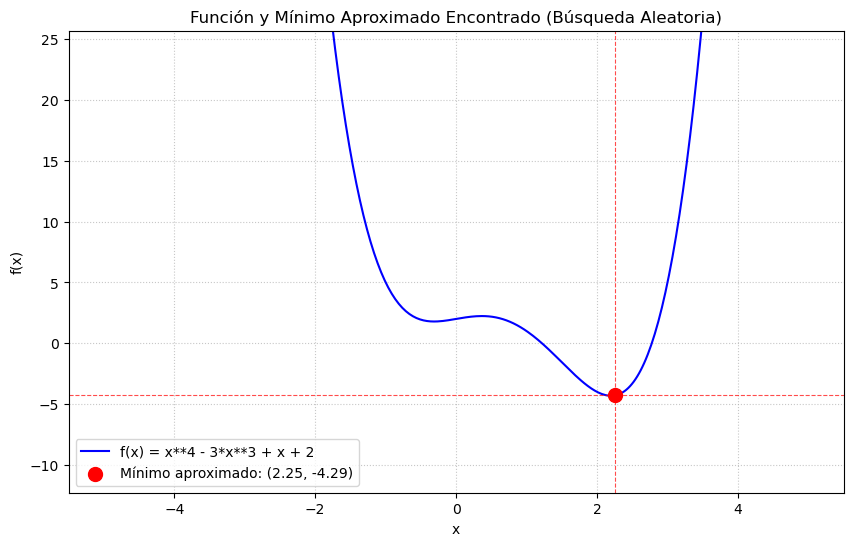

In [19]:
# Generar puntos para graficar la función
x_vals = np.linspace(a_intervalo, b_intervalo, 400)
y_vals = funcion_ejemplo(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = '+fn, color='blue')
plt.scatter(
    x_min_encontrado,
    f_min_encontrado,
    color='red',
    marker='o',
    s=100,
    label=f'Mínimo aproximado: ({x_min_encontrado:.2f}, {f_min_encontrado:.2f})',
    zorder=5
)
plt.axvline(x=x_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=f_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(f_min_encontrado - 8, f_min_encontrado + 30)

plt.title('Función y Mínimo Aproximado Encontrado (Búsqueda Aleatoria)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

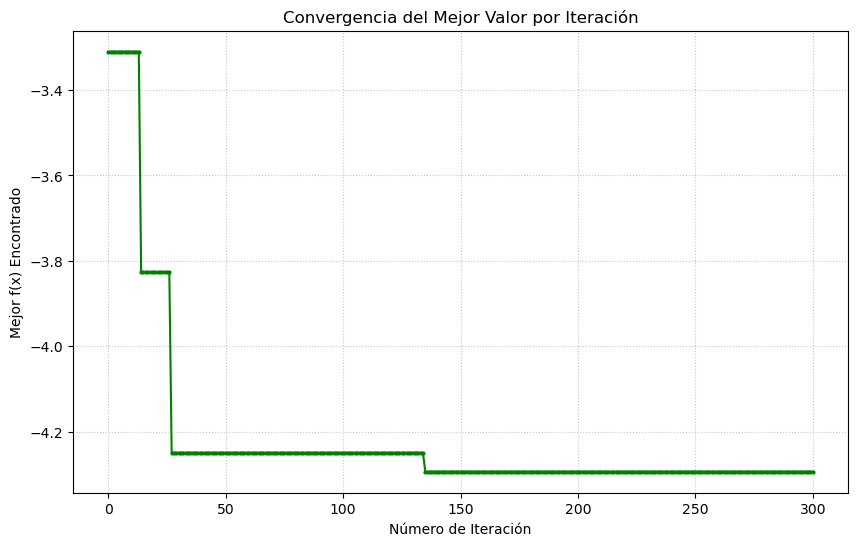

Historial (primeras 10 y últimas 5 iteraciones):
   Iteración  Mejor f(x)
0          0   -3.310195
1          1   -3.310195
2          2   -3.310195
3          3   -3.310195
4          4   -3.310195
5          5   -3.310195
6          6   -3.310195
7          7   -3.310195
8          8   -3.310195
9          9   -3.310195
...
     Iteración  Mejor f(x)
296        296   -4.294028
297        297   -4.294028
298        298   -4.294028
299        299   -4.294028
300        300   -4.294028


In [20]:
# Extraer iteraciones y mejor valor observado
iteraciones = [item[0] for item in historial_error_min]
mejor_valor = [item[1] for item in historial_error_min]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones, mejor_valor, marker='o', linestyle='-', color='green', markersize=2)
plt.title('Convergencia del Mejor Valor por Iteración')
plt.xlabel('Número de Iteración')
plt.ylabel('Mejor f(x) Encontrado')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

df_error = pd.DataFrame(historial_error_min, columns=['Iteración', 'Mejor f(x)'])
print('Historial (primeras 10 y últimas 5 iteraciones):')
print(df_error.head(10))
print('...')
print(df_error.tail(5))